'/content/archive (13).zip' unzipped to '/content/'.
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1            

/tmp/ipykernel_6037/759577518.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_6037/759577518.py:60: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

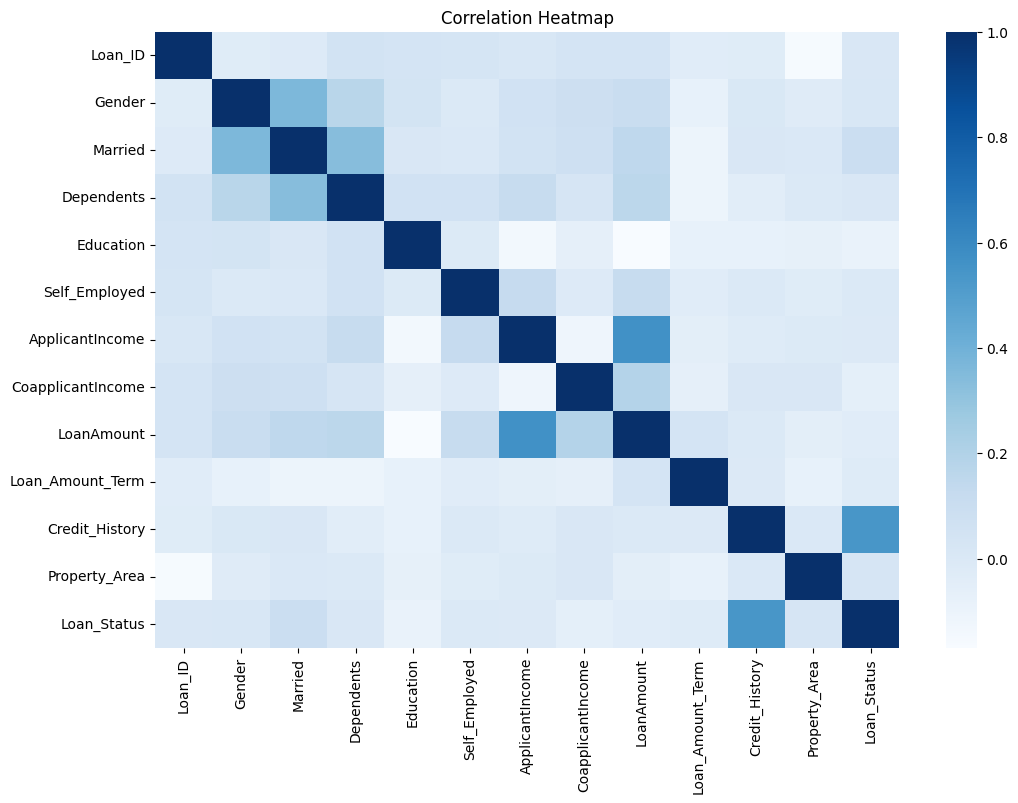

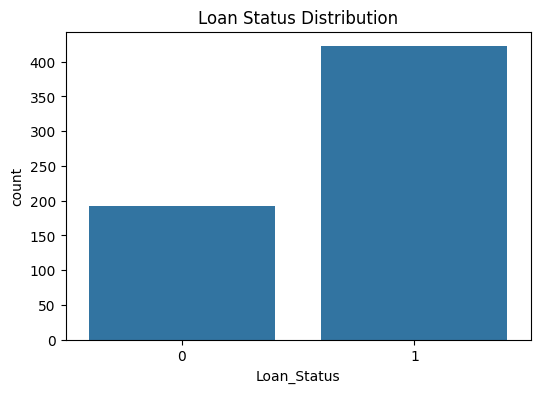

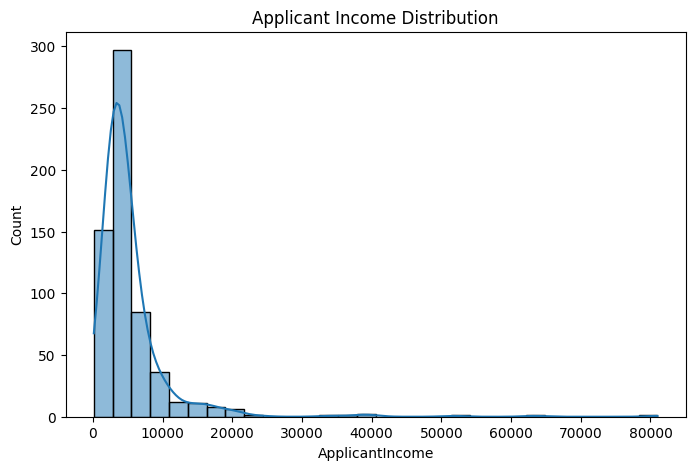

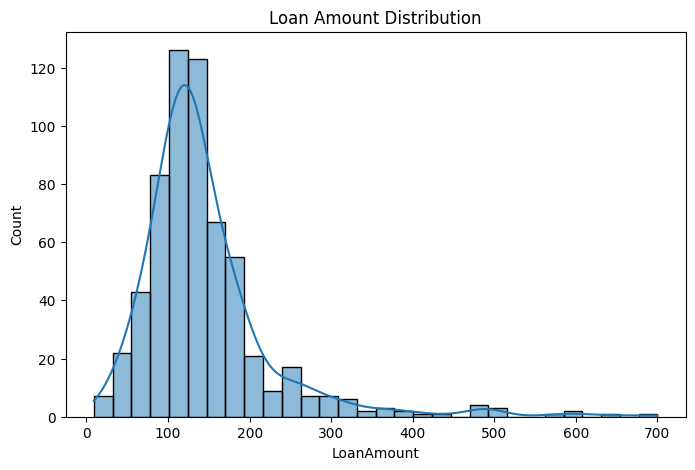

Accuracy: 0.6910569105691057

Classification Report
              precision    recall  f1-score   support

           0       0.56      0.51      0.54        43
           1       0.75      0.79      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.65       123
weighted avg       0.69      0.69      0.69       123


Confusion Matrix
[[22 21]
 [17 63]]


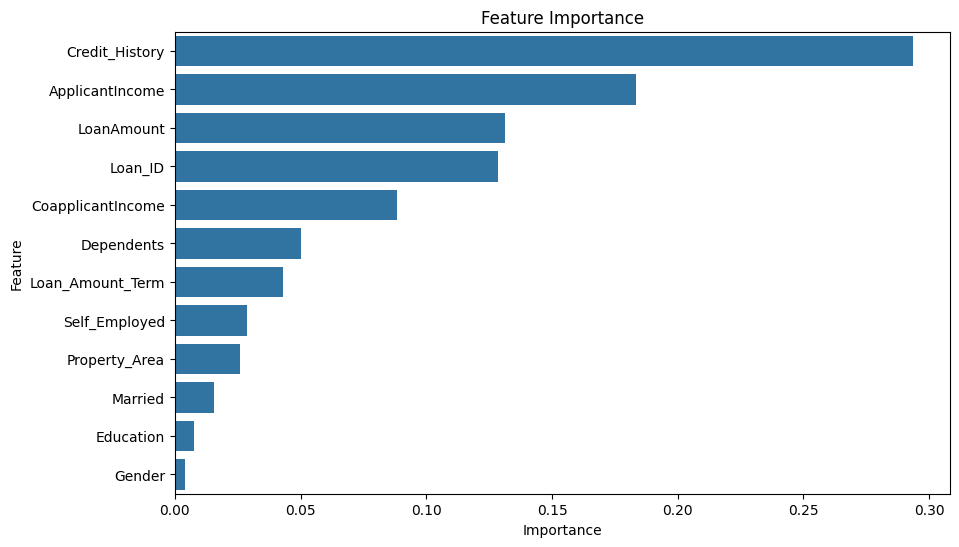


Top Important Features
              Feature  Importance
10     Credit_History    0.293493
6     ApplicantIncome    0.183381
8          LoanAmount    0.131234
0             Loan_ID    0.128363
7   CoapplicantIncome    0.088375
3          Dependents    0.050325
9    Loan_Amount_Term    0.043204
5       Self_Employed    0.028539
11      Property_Area    0.026054
2             Married    0.015446
4           Education    0.007550
1              Gender    0.004036


In [4]:
# ===============================
# Project 6 - Bank Loan Analysis
# ===============================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------------
# Unzip Dataset (if necessary)
# -------------------------------
# Assuming the CSV files are inside 'archive (13).zip'
zip_file_path = '/content/archive (13).zip'
extract_path = '/content/'

if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"'{zip_file_path}' unzipped to '{extract_path}'.")
else:
    print(f"Zip file not found at '{zip_file_path}'. Please ensure it's uploaded or the path is correct.")

# -------------------------------
# Load Dataset
# -------------------------------
# After unzipping, load the training CSV file
df = pd.read_csv(os.path.join(extract_path, "train_u6lujuX_CVtuZ9i.csv"))

# Display first rows
print(df.head())

# Dataset Information
print(df.info())

# Check Missing Values
print(df.isnull().sum())

# -------------------------------
# Handle Missing Values
# -------------------------------

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Verify
print(df.isnull().sum())

# -------------------------------
# Encode Categorical Variables
# -------------------------------

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

# -------------------------------
# Correlation Heatmap
# -------------------------------

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# Loan Status Distribution
# -------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()

# -------------------------------
# Applicant Income Distribution
# -------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df['ApplicantIncome'], bins=30, kde=True)
plt.title("Applicant Income Distribution")
plt.show()

# -------------------------------
# Loan Amount Distribution
# -------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], bins=30, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

# -------------------------------
# Feature Selection
# -------------------------------

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# -------------------------------
# Train Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -------------------------------
# Model Training
# -------------------------------

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

# -------------------------------
# Prediction
# -------------------------------

y_pred = model.predict(X_test)

# -------------------------------
# Evaluation
# -------------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# -------------------------------
# Feature Importance
# -------------------------------

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title("Feature Importance")
plt.show()

print("\nTop Important Features")
print(importance)
